In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

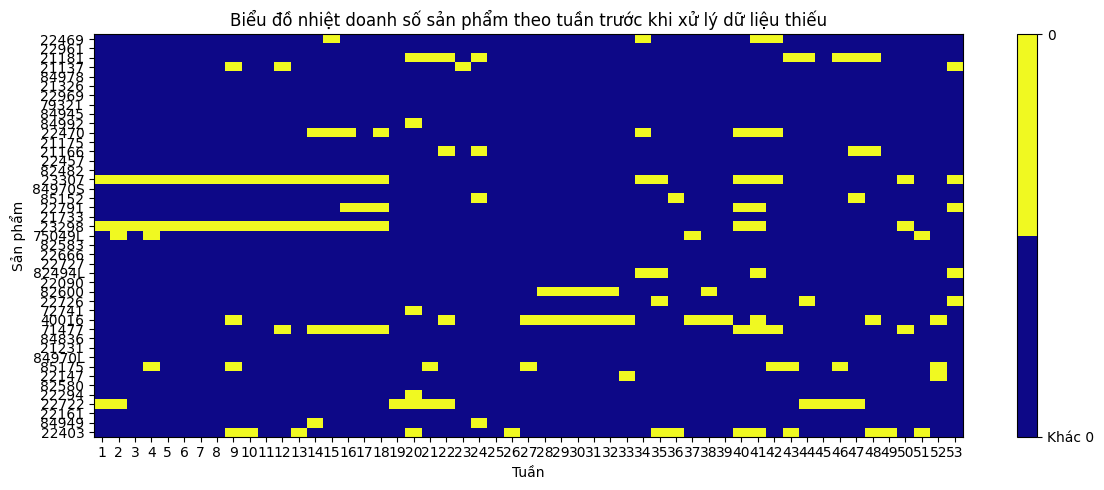

In [7]:
df = pd.read_csv("../dataset/quantity_weekly_decor.csv", index_col=0)

zero_mask = (df == 0).astype(int)
cmap = ListedColormap([
    "#0d0887",
    "#f0f921"
])

plt.figure(figsize=(12, 5))
im = plt.imshow(zero_mask, aspect="auto", interpolation="nearest", cmap=cmap)

plt.title("Biểu đồ nhiệt doanh số sản phẩm theo tuần trước khi xử lý dữ liệu thiếu")
plt.xlabel("Tuần")
plt.ylabel("Sản phẩm")

plt.xticks(ticks=np.arange(df.shape[1]), labels=df.columns)
plt.yticks(ticks=np.arange(df.shape[0]), labels=df.index)

cbar = plt.colorbar(im, ticks=[0, 1])
cbar.ax.set_yticklabels(["Khác 0", "0"])

plt.tight_layout()
plt.show()

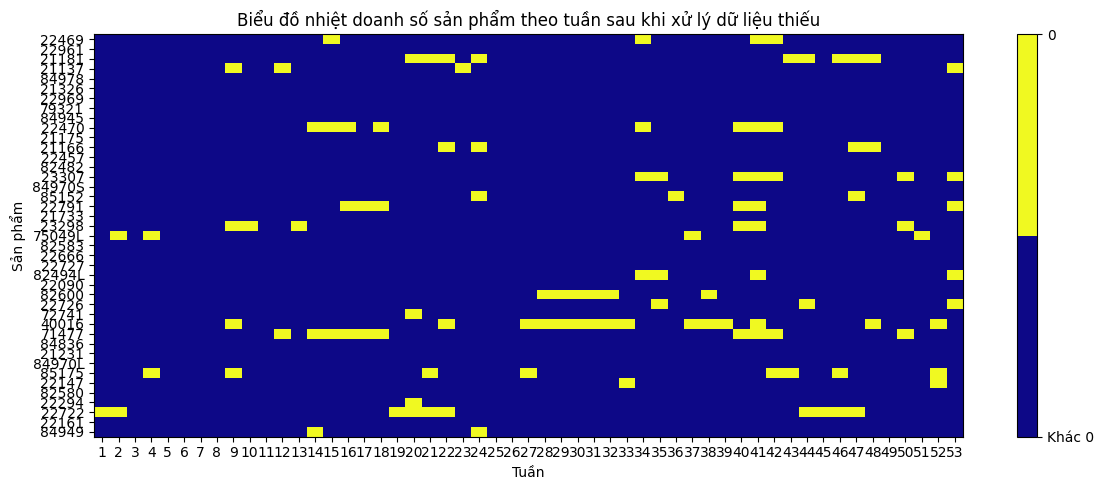

In [8]:
df = pd.read_csv("../dataset/quantity_weekly_decor_cooked.csv", index_col=0)

zero_mask = (df == 0).astype(int)
cmap = ListedColormap([
    "#0d0887",
    "#f0f921"
])

plt.figure(figsize=(12, 5))
im = plt.imshow(zero_mask, aspect="auto", interpolation="nearest", cmap=cmap)

plt.title("Biểu đồ nhiệt doanh số sản phẩm theo tuần sau khi xử lý dữ liệu thiếu")
plt.xlabel("Tuần")
plt.ylabel("Sản phẩm")

plt.xticks(ticks=np.arange(df.shape[1]), labels=df.columns)
plt.yticks(ticks=np.arange(df.shape[0]), labels=df.index)

cbar = plt.colorbar(im, ticks=[0, 1])
cbar.ax.set_yticklabels(["Khác 0", "0"])

plt.tight_layout()
plt.show()

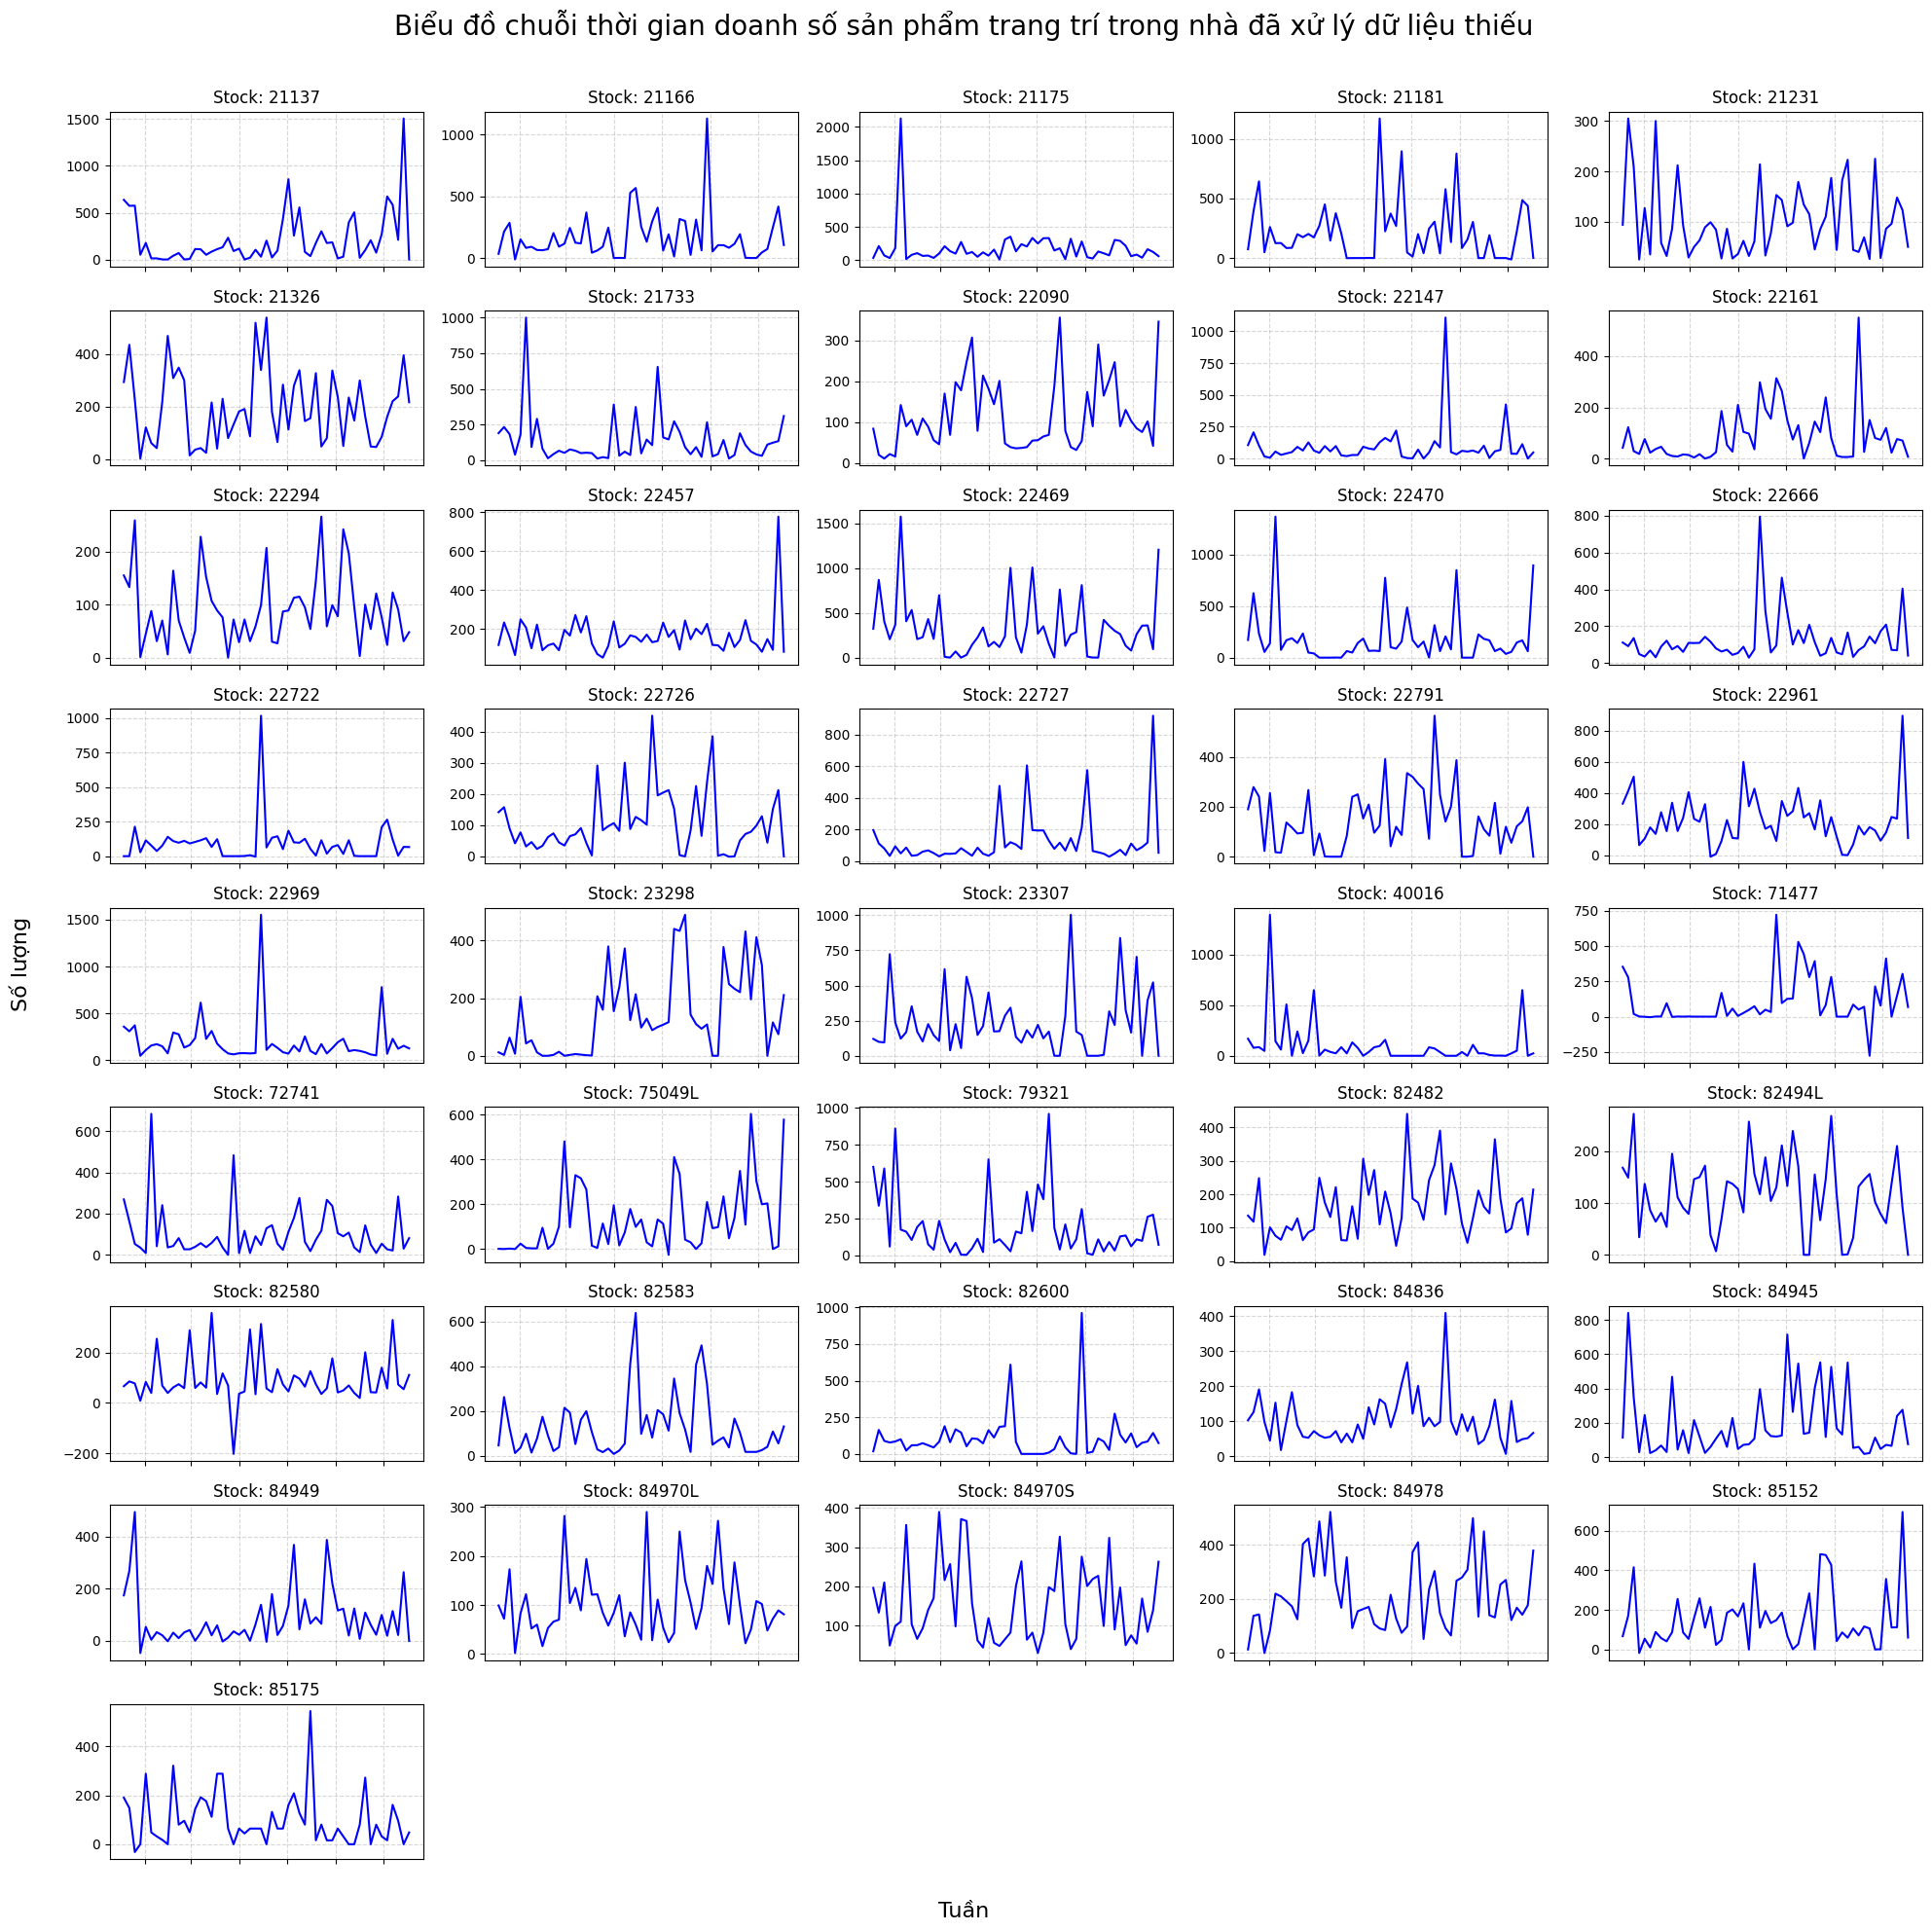

In [10]:
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/quantity_weekly_decor_cooked.csv")

df_melted = df.melt(id_vars=['StockCode'], var_name='Week', value_name='Quantity')

# Tạo dãy ngày bắt đầu từ 2010-12-01 (mỗi tuần một lần)
# Tạo dictionary để map Week_1 -> 2010-12-01, Week_2 -> 2010-12-08...
weeks = [f'{i}' for i in range(1, 54)]
dates = pd.date_range(start='2010-12-01', periods=53, freq='W')
date_map = dict(zip(weeks, dates))

df_melted['Date'] = df_melted['Week'].map(date_map)
ts_data = df_melted.pivot(index='Date', columns='StockCode', values='Quantity')

fig, axes = plt.subplots(nrows=9, ncols=5, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, stock_code in enumerate(ts_data.columns):
    if i < 45:
        axes[i].plot(ts_data.index, ts_data[stock_code], color='blue', linewidth=1.5)
        axes[i].set_title(f"Stock: {stock_code}")
        axes[i].tick_params(axis='both', which='major')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='x', which='both', labelbottom=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.text(0.5, 0.01, 'Tuần', ha='center', fontsize=16)
fig.text(0.01, 0.5, 'Số lượng', va='center', rotation='vertical', fontsize=16)

plt.suptitle("Biểu đồ chuỗi thời gian doanh số sản phẩm trang trí trong nhà đã xử lý dữ liệu thiếu", fontsize=20, y=0.99)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.show()